In [1]:
import torch 
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from matplotlib import colors, cm

**GOAL**: We want to find sign-changing (non-trivial) solutions of the nonlinear elliptic equation
$$-\Delta_{Sph} u= u|u|^{p-2}, \quad p>2$$
where $u: \mathbb{S}^2 \to \mathbb{R}$, $\Delta_{Sph}$ is the spherical Laplacian on $\mathbb{S}^2$. How to express the spherical Laplacian? There are two ways :
- We see $f$ as a function in the local coordinates $(\theta, \phi)$ on $\mathbb{S}^2$ ($\theta$ is the polar angle between the north pole and the point, $\phi$ is the azimutal angle along the radial line), then the Laplacian is written in *intrinsic* coordinates as
$$
    \Delta_{Sph} f(\theta, \phi) = \frac{1}{\sin \theta} \frac{\partial}{\partial \theta}\Big(\sin \theta \frac{\partial f}{\partial \theta}\Big) + \frac{1}{\sin^2 \theta} \frac{\partial^2 f}{\partial \theta^2}
$$ 
The problem here is that the expression becomes singular when evaluated at the poles ($\theta = 0$ and $\theta = \pi$);
- We see $\mathbb{S}^2$ as the subset of $\mathbb{R}^3$
$$  \mathbb{S}^2 = \{x=(x_1,x_2,x_3) \,: \, |x| = 1\},
$$
and $f$ as a function of 3 variables $x_1,x_2,x_3$, that we only evaluate at $x= (x_1,x_2,x_3) \in \mathbb{S}^2$. Then starting from the definition of the 3D Laplacian in spherical coordinates $(r,\theta,\phi)$,
\begin{align}  
    \Delta_{3D}f &=\frac{1}{r^2} \frac{\partial}{\partial r}\Big(r^2 \frac{\partial f}{\partial r}\Big) + \frac{1}{r^2}\Delta_{Sph}f\\
        &= \frac{\partial^2 f}{\partial x_1^2} +\frac{\partial^2 f}{\partial x_2^2} + \frac{\partial^2 f}{\partial x_3^2},
\end{align}
we can express the spherical Laplacian in *extrinsic* coordinates as
$$  \Delta_{Sph} f(x_1,x_2,x_3) = (1-x_1^2)\frac{\partial^2 f}{\partial x_1^2} + (1-x_2^2)\frac{\partial^2 f}{\partial x_2^2} + (1-x_3^2)\frac{\partial^2 f}{\partial x_3^2} - 2 \Big(x_1 x_2 \frac{\partial^2 f}{\partial x_1 x_2} + x_1 x_3 \frac{\partial^2 f}{\partial x_1 x_3} + x_2 x_3 \frac{\partial^2 f}{\partial x_2 x_3} + x_1 \frac{\partial f}{\partial x_1} + x_2 \frac{\partial f}{\partial x_2} + x_3 \frac{\partial f}{\partial x_3}\Big)
$$ 

In [49]:
p = 3

def loss_fn(model, x, y, z, x0, y0, z0, u0):
    u = model(x, y, z, x0, y0, z0, u0)
    dudx, dudy, dudz = torch.autograd.grad(u, [x, y, z], grad_outputs=torch.ones_like(u), create_graph=True)
    d2udx2, d2udxdy, d2udxdz = torch.autograd.grad(dudx, [x, y, z], grad_outputs=torch.ones_like(dudx), create_graph=True)
    d2udy2, d2udydz = torch.autograd.grad(dudy, [y,z], grad_outputs=torch.ones_like(dudy), create_graph=True)
    d2udz2 = torch.autograd.grad(dudz, z, grad_outputs=torch.ones_like(dudz), create_graph=True)[0]
    laplacian = (1-x**2)*d2udx2 + (1-y**2)*d2udy2 + (1-z**2)*d2udz2 - 2* (x*y* d2udxdy + x*z* d2udxdz + y*z* d2udydz + x*dudx + y*dudy + z*dudz)
    return ((u * torch.abs(u)**(p-2)+ laplacian)**2).mean()

If $nn$ is a function (representing the model), $x_0,x_1 \in \mathbb{S}^2$, $u_0, u_1 \in \mathbb{R}$ then 
$$  u(x) := nn(x) \cdot \frac{|x-x_0||x-x_1|}{|x_0-x_1|} + u_0 \cdot \frac{|x-x_1|}{|x_0-x_1|} + u_1 \cdot \frac{|x-x_0|}{|x_0-x_1|}\quad \forall ~x \in \mathbb{S}^2$$
is a function such that $u(x_0) = u_0$ and $u(x_1) = u_1$.

Without loss of generality, we impose $x_1$ to be the north pole $x_1 = (0,0,1) \in \mathbb{S}^2$, $u_1=0$ (ok since $u$ must be sign-changing).

In [50]:
def get_sin_cos(theta, phi):
    return [torch.sin(theta)*torch.cos(phi), torch.sin(theta)*torch.sin(phi), torch.cos(theta)]

class Model(nn.Module):
    def __init__(self, layer_size=64):
        super().__init__()
        self.nn = nn.Sequential(
            nn.Linear(7, layer_size), nn.ReLU(),
            nn.Linear(layer_size, layer_size), nn.ReLU(),
            nn.Linear(layer_size, layer_size), nn.ReLU(),
            nn.Linear(layer_size, layer_size), nn.ReLU(),
            nn.Linear(layer_size, layer_size), nn.ReLU(),
            nn.Linear(layer_size, layer_size), nn.ReLU(),
            nn.Linear(layer_size, layer_size), nn.ReLU(),
            nn.Linear(layer_size, layer_size), nn.ReLU(),
            nn.Linear(layer_size, 1)
        )

    def forward(self, x, y, z, x0, y0, z0, u0):
        return (self.nn(torch.concatenate([x, y, z, x0, y0, z0, u0], axis=-1)) * \
                (torch.abs(x) + torch.abs(y) + torch.abs(z-1))) * (torch.abs(x-x0) + torch.abs(y-y0) + torch.abs(z-z0))/(torch.abs(x0) + torch.abs(y0) + torch.abs(z0-1)) \
        + u0*(torch.abs(x)+torch.abs(y) + torch.abs(z-1))/(torch.abs(x0) + torch.abs(y0) + torch.abs(z0-1))

We train $nn$ on various pointwise conditions $(x_0,u_0)$, $x_0\in \mathbb{S}^2$, $u_0 \in [-2,2]$ : We set $u(x_0)=u_0$, thanks to the expression above. 

By symmetry of the problem, we can choose $x_0$ along the parallel $\phi = 0$, and $u_0$ positive only. 

We observe that the model does not converge when $x_0$ is too close to the north pole (where we impose the condition $u(x_1) = 0$), so that we further restrict $x_0$ to be taken in the spherical zone $\theta_0 \in [0.5,\pi]$.

In [61]:
torch.set_default_device('mps')
model = Model()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=50)

n_points = 1000
n_epochs = 1000
U_MAX = 3
U_MIN = 1

for _ in (pbar:=tqdm(range(n_epochs))):
    optimizer.zero_grad()
    
    theta0 = torch.rand((n_points, 1), requires_grad=True) * (torch.pi-0.5) + 0.5
    u0 = ((torch.rand((n_points, 1), requires_grad=True)) * (U_MAX-U_MIN)) + U_MIN
    theta = torch.rand((n_points, 1), requires_grad=True) * torch.pi
    phi = torch.rand((n_points, 1), requires_grad=True) * 2 * torch.pi
    
    loss = loss_fn(model, *get_sin_cos(theta, phi), *get_sin_cos(theta0, torch.zeros_like(theta0, requires_grad=True)), u0)
    loss.backward()
    optimizer.step()
    lr_scheduler.step(loss.item())
    pbar.set_description(f"Loss: {loss.item():.4e}")

  0%|          | 0/1000 [00:00<?, ?it/s]

In [62]:
def plot_model(model, theta0, u0, xlim=(0, torch.pi), ylim=(0, 2*torch.pi), n=200, device=None):
    xs = torch.linspace(xlim[0], xlim[1], n, device=device)
    ys = torch.linspace(ylim[0], ylim[1], n, device=device)
    X, Y = torch.meshgrid(xs, ys, indexing="xy")
    x = X.reshape(-1, 1)
    y = Y.reshape(-1, 1)
    theta0_t = torch.full_like(x, float(theta0))
    u0_t = torch.full_like(x, float(u0))
    with torch.no_grad():
        out = model(*get_sin_cos(x, y), *get_sin_cos(theta0_t, torch.zeros_like(theta0_t)), u0_t)
    out = out.reshape(n, n, 1).cpu().numpy()
    X_np, Y_np = X.cpu().numpy(), Y.cpu().numpy()
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(projection='3d')
    vmax = np.max(np.abs(out))
    norm = colors.Normalize(vmin=-vmax, vmax=vmax)
    m = cm.ScalarMappable(norm=norm, cmap='seismic')
    m.set_array(out[..., 0])
    
    ax.plot_surface(
        *get_sin_cos(torch.tensor(X_np), torch.tensor(Y_np)),
        facecolors=m.to_rgba(out[..., 0]),
        shade=False,
    )
    fig.colorbar(m, ax=ax)
    ax.set_aspect('equal')
    plt.title(f"theta0 = {theta0}, phi0 = 0, u0 = {u0}")
    plt.tight_layout()
    plt.show()

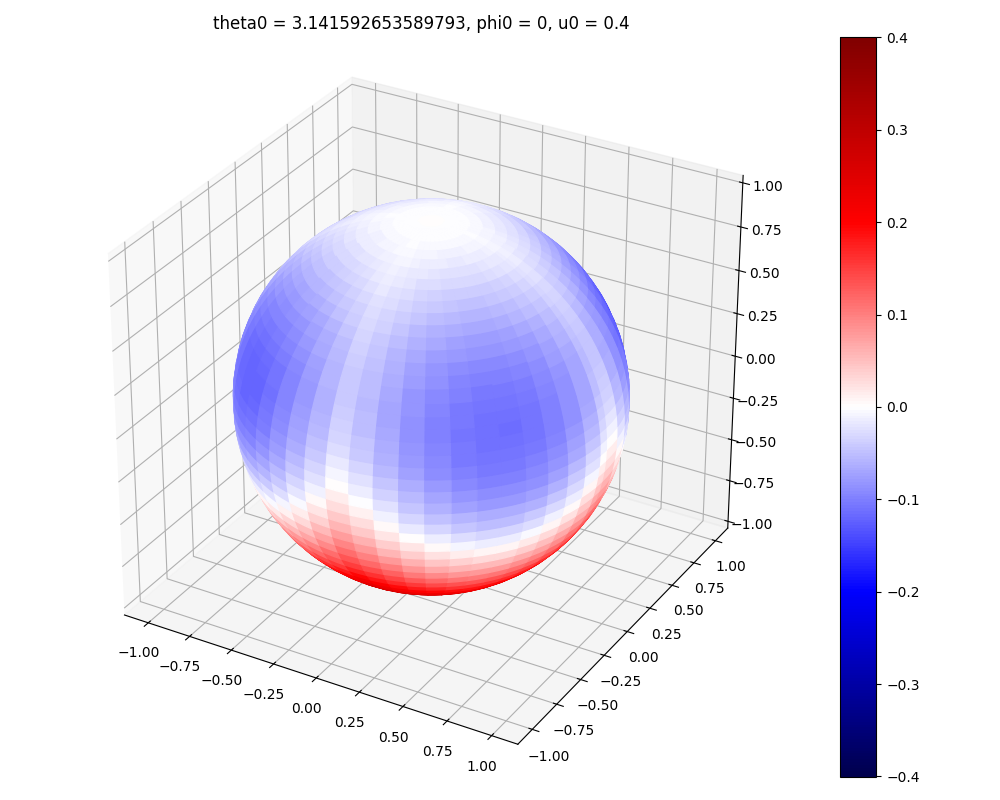

In [68]:
%matplotlib widget
plt.close()
torch.set_default_device('cpu')
plot_model(model.cpu(), theta0=torch.pi, u0=0.4, n=100)

In [69]:
n_points = 100

xs = torch.linspace(0, torch.pi, n_points, requires_grad=True)
ys = torch.linspace(0, 2*torch.pi, n_points, requires_grad=True)
X, Y = torch.meshgrid(xs, ys, indexing="xy")
x = X.reshape(-1, 1)
y = Y.reshape(-1, 1)
theta0 = torch.tensor([6*torch.pi/25], requires_grad=True).expand((n_points**2,1))
u0 = torch.tensor([0.5], requires_grad=True).expand((n_points**2, 1))

print(loss_fn(model, *get_sin_cos(x, y), *get_sin_cos(theta0, torch.zeros_like(theta0)), u0).mean().item())

0.9255712032318115


How does the loss vary with respect to the pointwise condition $(x_0, u_0)$?

In [70]:
torch.set_default_device('mps')
model.to('mps')
n_points = 25
xs = torch.linspace(0, torch.pi, n_points, requires_grad=True)    
ys = torch.linspace(0, 2*torch.pi, n_points, requires_grad=True)
X, Y = torch.meshgrid(xs, ys, indexing="xy")
x = X.reshape(-1, 1)
y = Y.reshape(-1, 1)

theta0s = torch.linspace(0.5, torch.pi, n_points, requires_grad=True) #### AJOUTÉ theta va de 0.1 à pi pour éviter x_0 = x_1 et model = nan
u0s = torch.linspace(0, 2, n_points, requires_grad=True)

losses = np.array([[loss_fn(model, *get_sin_cos(x, y), 
                   *get_sin_cos(torch.tensor(theta0, requires_grad=True).expand((n_points**2,1)), torch.tensor([0.], requires_grad=True).expand((n_points**2,1))), 
                   u0*torch.ones_like(torch.tensor(theta0, requires_grad=True).expand((n_points**2,1)))).item() for theta0 in theta0s] for u0 in tqdm(u0s)])

  0%|          | 0/25 [00:00<?, ?it/s]

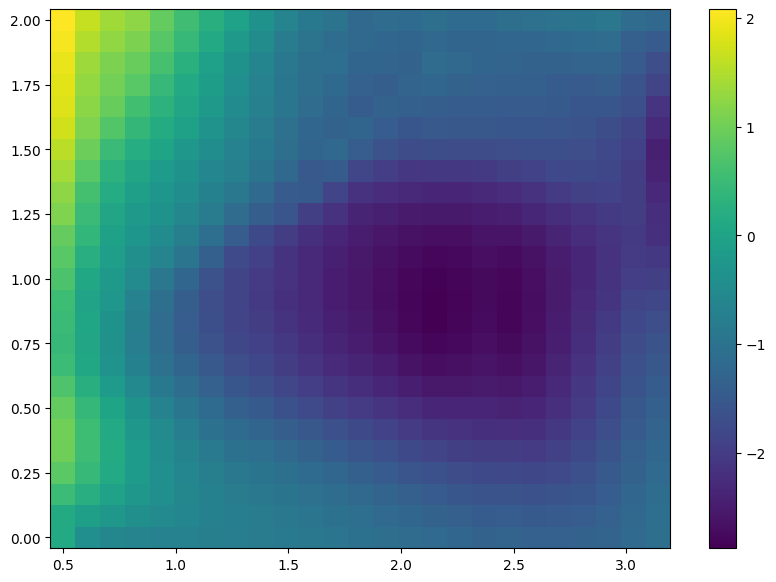

In [71]:
plt.close()
%matplotlib inline
plt.figure(figsize=(10, 7))
plt.pcolormesh(theta0s.detach().cpu().numpy(), u0s.detach().cpu().numpy(), np.log(losses))
plt.colorbar()
plt.show()

0.05627443268895149


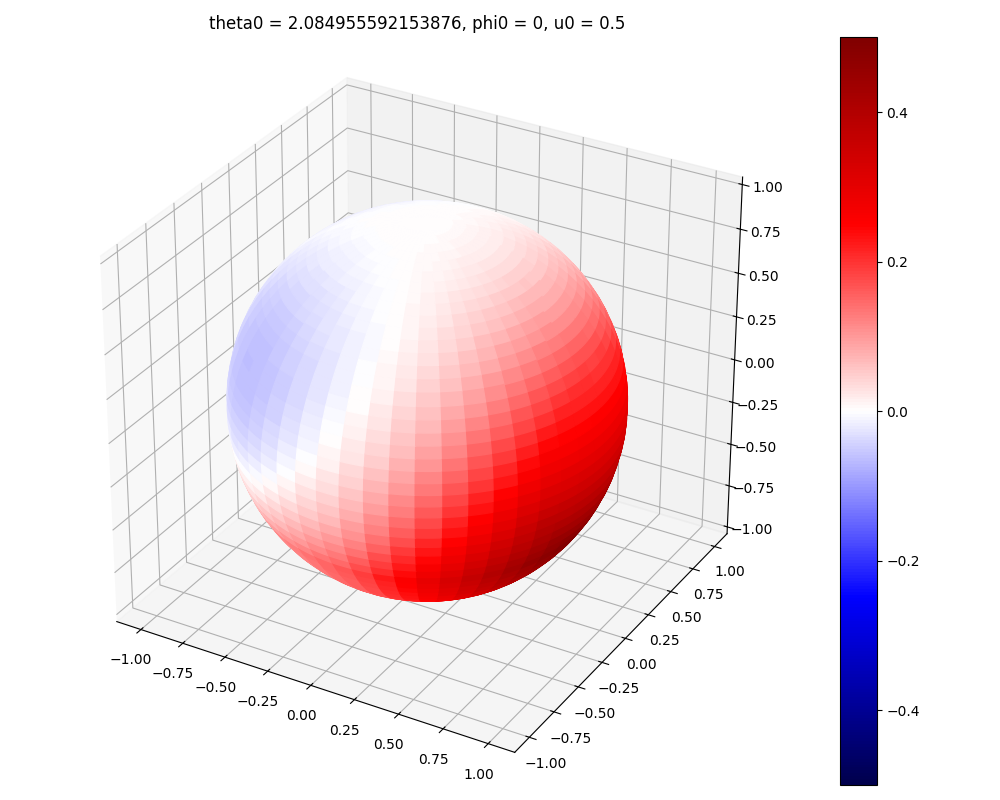

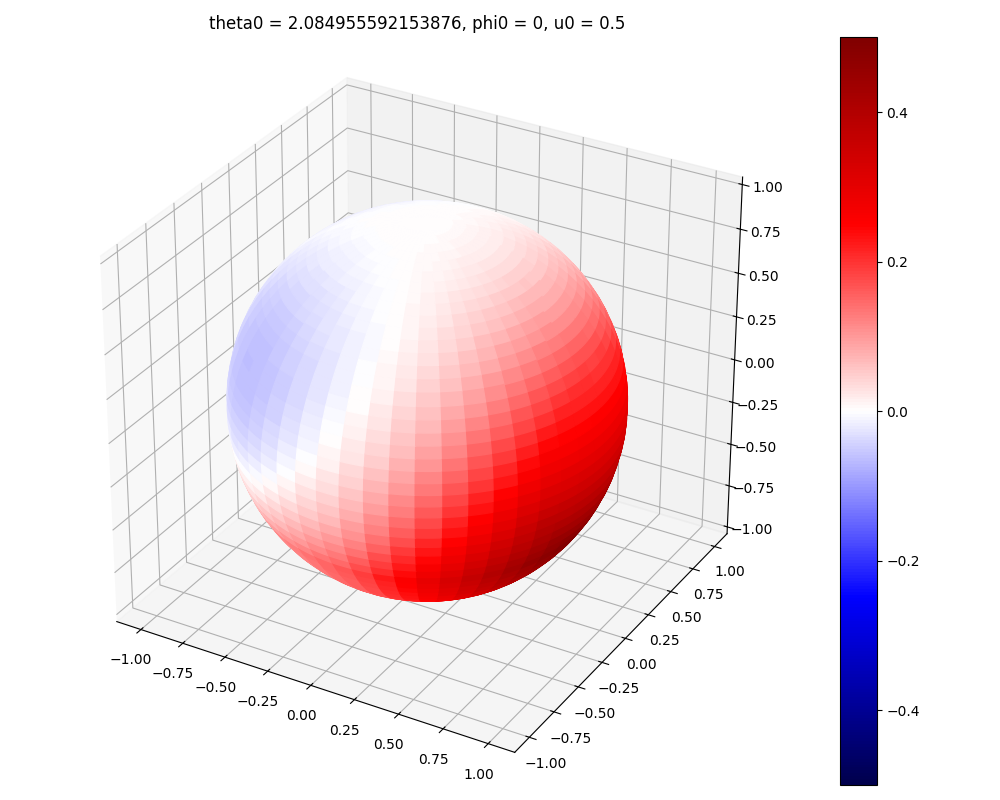

In [74]:
print(losses[np.argmin(losses)//n_points, np.argmin(losses)%n_points])

%matplotlib widget
plt.close()
torch.set_default_device('cpu')
u0 = 0.5#(np.argmin(losses)//n_points) * 2/n_points
theta0 = (np.argmin(losses)%n_points) * (torch.pi-0.5)/n_points + 0.5
plot_model(model.cpu(), theta0=theta0, u0=u0, n=200)
plt.show()